# Student Performance ANN Project
Data analysis, preprocessing, training, and model saving.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [2]:
df = pd.read_csv("../data/AirPassengers.csv")

df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [3]:
# Data analysis
print(df.info())
print(df.describe())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None
       #Passengers
count   144.000000
mean    280.298611
std     119.966317
min     104.000000
25%     180.000000
50%     265.500000
75%     360.500000
max     622.000000
Month          0
#Passengers    0
dtype: int64


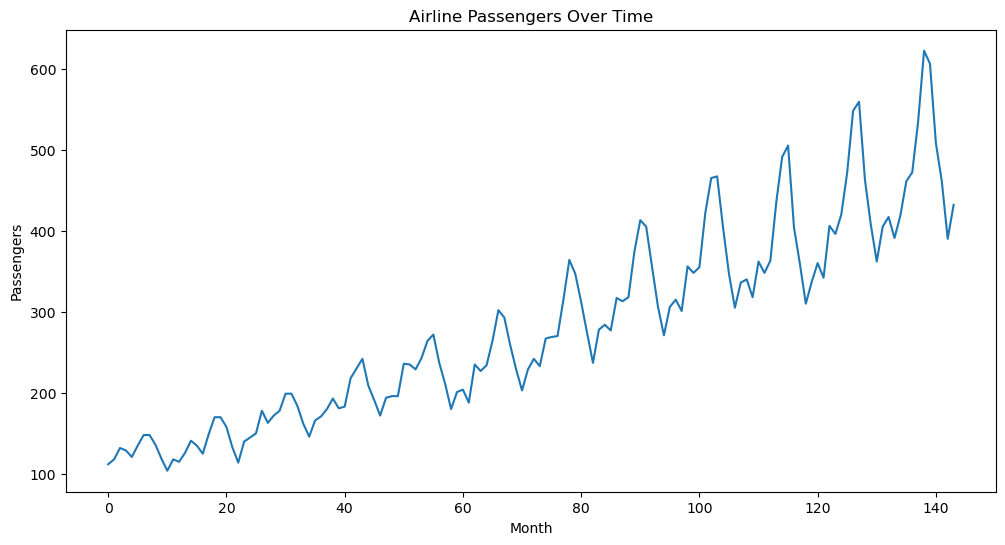

In [5]:
plt.figure(figsize=(12,6))
plt.plot(df["#Passengers"])
plt.title("Airline Passengers Over Time")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.show()

In [8]:
scaler = MinMaxScaler()

data = scaler.fit_transform(
    df[["#Passengers"]]
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [9]:
X = []
y = []

window_size = 12

for i in range(window_size, len(data)):
    X.append(
        data[i-window_size:i, 0]
    )

    y.append(
        data[i, 0]
    )

X = np.array(X)
y = np.array(y)

X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

print(X.shape)
print(y.shape)

(132, 12, 1)
(132,)


In [10]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [11]:
model = Sequential()

model.add(
    SimpleRNN(
        50,
        activation="tanh",
        input_shape=(12,1)
    )
)

model.add(
    Dense(1)
)

model.compile(
    optimizer="adam",
    loss="mse"
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8,
    validation_data=(X_test,y_test)
)

c:\Users\harsh\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0143 - val_loss: 0.0136
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0039 - val_loss: 0.0123
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0017 - val_loss: 0.0162
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0015 - val_loss: 0.0170
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0018 - val_loss: 0.0104
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011 - val_loss: 0.0125
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0012 - val_loss: 0.0087
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0012 - val_loss: 0.0060
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.8591e-04 - val_loss: 0.0085
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8.2894e-04 - val_loss: 0.0079
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8.8889e-04 - val_loss: 0.0090
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 

In [12]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(
    predictions
)

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

print("RMSE:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
RMSE: 29.518378736436937


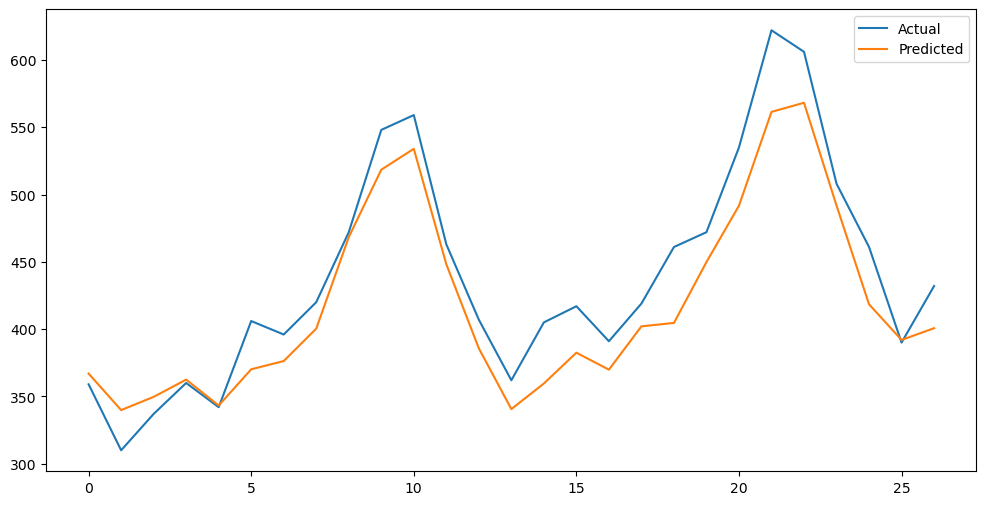

In [13]:
plt.figure(figsize=(12,6))

plt.plot(
    actual,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.legend()

plt.show()

In [15]:
model.save(
    "../models/airline_rnn.keras"
)

print("Model Saved")

Model Saved
